# AAV2 -- Analyse detaillee + filtre `viab` + regression de Potts

Meme methode que sur AAV5 cette session : analyse detaillee du dataframe (comptages, contamination,
discretisation), dithering pour distinguer bimodalite reelle d'artefact de comptage, sweep de seuil
informe par les donnees plutot que choisi a l'oeil, puis tentative de recuperation des poids de
Potts (F_viab/J_viab) par regression ridge directement sur les donnees reelles filtrees.

Terminologie respectee : log enrichment, jamais "score" pour une prediction/mesure. Pseudocount
`eps=0.5` partout ou on recalcule nous-memes un log enrichment (convention permanente du projet).

**⚠ 2026-09-18 : régression de Potts reconstruite avec le nouveau solveur par défaut du projet** (`RegressionV1.fit_weights_potts_from_data_matrixfree` -- matrix-free, plus de matrice de design dense matérialisée ; validé pour reproduire le solve classique quasi exactement, `r(F)`/`r(J) > 0.999999` sur données AAV2 réelles -- cf. `viability/AAV2_potts_ridge_matrixfree_validation.ipynb`). Même signature d'appel/retour que l'ancienne `fit_weights_potts_from_data` (`rank` vaut toujours `None` ici -- pas de diagnostic SVD avec un solveur itératif). L'ancienne version de ce notebook (solveur dense/SVD) est archivée dans `obsolete_dense_matrix_potts_regression/`. **Sorties de cellules effacées** (méthode de fit changée, anciens chiffres plus valides) -- à ré-exécuter. Notebook préparé mais **jamais exécuté par Claude** (`feedback_user_runs_notebooks`).

## 1. Chargement + vue d'ensemble

In [14]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # 2026-09-18 -- sans ca, JAX (importe plus
# loin via RegressionV1) preallouait ~75-90% du pool memoire unifie GPU/CPU de cette machine des
# le premier fit (~94 Go observes), independamment de la taille reelle du calcul -- ce notebook
# etait le seul des 6 reconstruits a ne pas deja avoir cette ligne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

CSV_PATH = Path("AAV2_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/AAVs dataset/AAV2/AAV2_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH

viab_col = "log2_enrichissement_virus_sur_plasmide"
use = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}
df = pd.read_csv(CSV_PATH, usecols=use, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes  (colonnes completes du CSV : 34, dont "
      f"organoide/noyaux ADN+ARN -- pas chargees ici, hors-scope viabilite)")
print("longueur de sequence (doit etre 7 partout) :", df['sequence'].str.len().unique())

4,273,463 lignes x 4 colonnes  (colonnes completes du CSV : 34, dont organoide/noyaux ADN+ARN -- pas chargees ici, hors-scope viabilite)
longueur de sequence (doit etre 7 partout) : <IntegerArray>
[7]
Length: 1, dtype: Int64


## 2. Distributions `compte_plasmide` / `compte_virus`

In [15]:
p = df["compte_plasmide"].to_numpy(np.float64)
v = df["compte_virus"].to_numpy(np.float64)
y = df[viab_col].to_numpy(np.float64)

print("compte_plasmide -- percentiles [0,1,5,10,25,50,75,90,99,99.9,100]:")
print(np.round(np.percentile(p, [0, 1, 5, 10, 25, 50, 75, 90, 99, 99.9, 100]), 2))
print(f"frac compte_plasmide == 0 : {(p == 0).mean():.2%}")
print()
print("compte_virus -- percentiles [0,1,5,10,25,50,75,90,99,99.9,100]:")
print(np.round(np.percentile(v, [0, 1, 5, 10, 25, 50, 75, 90, 99, 99.9, 100]), 2))
print(f"frac compte_virus == 0 : {(v == 0).mean():.2%}")
print()
print(f"viab fini : {np.isfinite(y).mean():.2%}  (n={np.isfinite(y).sum():,}) -- "
      f"coherent avec frac(plasmide==0) : le ratio est indefini exactement dans ce cas")
print()
print("quantum -- frac multiple exact de 1 (entier) :", np.isclose(p % 1, 0).mean(),
      np.isclose(v % 1, 0).mean(), " (PAS 0.5 comme AAV5 -- comptages entiers ici)")

compte_plasmide -- percentiles [0,1,5,10,25,50,75,90,99,99.9,100]:
[ 0.  0.  0.  0.  0.  1.  3.  6. 14. 23. 61.]
frac compte_plasmide == 0 : 34.23%

compte_virus -- percentiles [0,1,5,10,25,50,75,90,99,99.9,100]:
[1.00000e+00 1.00000e+00 1.00000e+00 1.00000e+00 1.00000e+00 3.00000e+00
 8.00000e+00 2.50000e+01 6.45000e+02 7.82054e+03 1.08106e+06]
frac compte_virus == 0 : 0.00%

viab fini : 65.77%  (n=2,810,598) -- coherent avec frac(plasmide==0) : le ratio est indefini exactement dans ce cas

quantum -- frac multiple exact de 1 (entier) : 1.0 1.0  (PAS 0.5 comme AAV5 -- comptages entiers ici)


## 3. Contamination plasmide -- y a-t-il un equivalent du 7m8 (AAV5) ?

Pour AAV5, un seul variant sur-represente (7m8/LGETTRP, ~4.8M reads plasmide, des ordres de
grandeur au-dessus du reste) polluait le classement. On regarde si un phenomene similaire existe
cote plasmide pour AAV2.

In [16]:
top_p = df.nlargest(15, "compte_plasmide")[["sequence", "compte_plasmide", "compte_virus", viab_col]]
print(top_p.to_string(index=False))
print()
print("-> Pas de spike-in evident : le top plasmide (max=61) decroit sans rupture nette, "
      "contrairement au 7m8 d'AAV5 qui etait a des ordres de grandeur du reste.")

sequence  compte_plasmide  compte_virus  log2_enrichissement_virus_sur_plasmide
 AGASERP             61.0         111.0                                0.818948
 IRRDLCA             61.0           8.0                               -2.975468
 SAMSRAP             61.0          43.0                               -0.549203
 TMAIEAA             56.0          24.0                               -1.267123
 VKWCFSM             56.0           2.0                               -4.852086
 FDRDLCA             55.0           1.0                               -5.826090
 NLMSRAP             55.0           5.0                               -3.504163
 TPAWSCN             54.0           7.0                               -2.992263
 AARAMEQ             51.0          16.0                               -1.717156
 ATEWPKP             51.0          43.0                               -0.290891
 TPAIEAA             51.0           7.0                               -2.909801
 ISGRLCA             50.0           3.0 

## 4. Contamination virus -- le vrai probleme sur ce dataset

`compte_virus` a un maximum de plus d'1 million, alors que `compte_plasmide` plafonne a 61 -- des
ratios `virus/plasmide` de plusieurs milliers a plusieurs dizaines de milliers apparaissent pour des
dizaines de variants, ce qui est biologiquement implausible (un facteur d'enrichissement de 2^18 ne
correspond a aucun mecanisme connu du protocole). Signature typique d'un artefact technique
(index-hopping / contamination croisee entre echantillons sur le meme run de sequencage) plutot que
d'un spike-in identifiable par sequence -- pas de cluster hamming-proche d'une sequence connue ici,
contrairement au 7m8 d'AAV5.

In [17]:
top_v = df.nlargest(15, "compte_virus")[["sequence", "compte_plasmide", "compte_virus", viab_col]]
print(top_v.to_string(index=False))
print()

m10 = p >= 10
ratio10 = v[m10] / p[m10]
print(f"Parmi les {m10.sum():,} variants avec compte_plasmide>=10 (denominateur deja raisonnable) :")
print("  ratio virus/plasmide -- percentiles [0,25,50,75,90,99,99.9,100]:")
print(np.round(np.percentile(ratio10, [0, 25, 50, 75, 90, 99, 99.9, 100]), 2))
print(f"  ratio>1000 : {int((ratio10 > 1000).sum())} variants ({(ratio10 > 1000).mean():.3%}) "
      f"-- implausible meme avec un denominateur fiable")

sequence  compte_plasmide  compte_virus  log2_enrichissement_virus_sur_plasmide
 EGNPNRF              3.0     1081060.0                               18.414322
 PDRAMGH              9.0      877578.0                               16.528511
 DPYDKRQ              1.0      640727.0                               19.244619
 EPTNNKG              1.0      551410.0                               19.028034
 IPGDRHL              1.0      541575.0                               19.002071
 GAHDRMT              0.0      518344.0                                     NaN
 DQQPQKI              5.0      471799.0                               16.481153
 GAKPEGH              1.0      445759.0                               18.721174
 GTGAGHM              4.0      444763.0                               16.717947
 GERVGRE              5.0      429528.0                               16.345734
 WCEKTNC              3.0      415884.0                               17.036129
 AADSQYK              0.0      400236.0 

## 5. Distribution brute de `log2_enrichissement_virus_sur_plasmide`

Histogramme (bins, jamais KDE -- convention du projet).

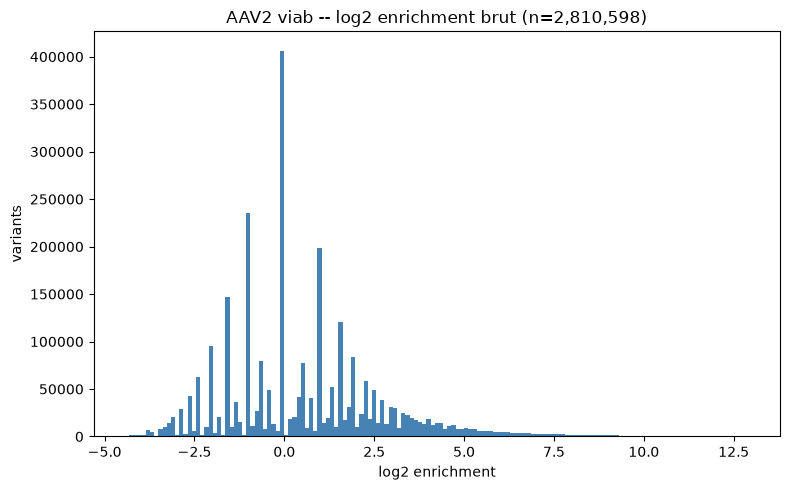

etendue : [-5.83, 19.24]  -- la queue au-dela de +10 est la contamination identifiee en section 4 (AAV5/AAV9 restaient sous ~+11, jamais +19)


In [18]:
yf = y[np.isfinite(y)]
fig, ax = plt.subplots(figsize=(8, 5))
lo, hi = np.percentile(yf, [0.05, 99.95])
ax.hist(yf, bins=np.linspace(lo, hi, 150), color="steelblue")
ax.set(title=f"AAV2 viab -- log2 enrichment brut (n={yf.size:,})",
       xlabel="log2 enrichment", ylabel="variants")
plt.tight_layout(); plt.show()
print(f"etendue : [{yf.min():.2f}, {yf.max():.2f}]  -- la queue au-dela de +10 est la "
      f"contamination identifiee en section 4 (AAV5/AAV9 restaient sous ~+11, jamais +19)")

## 6. Dithering sur le brut -- bimodalite reelle, ou pas ?

Meme technique que sur AAV5 (`AAV5_viab_sorting.ipynb`) : bruit `Uniform(-0.5,+0.5)` (quantum=1 ici,
pas 0.5) ajoute aux comptages avant de recalculer le ratio, pour juger de la vraie forme sans les
artefacts de discretisation. Uniquement sur les lignes `compte_plasmide>0` (sinon le ratio n'a pas
de sens).

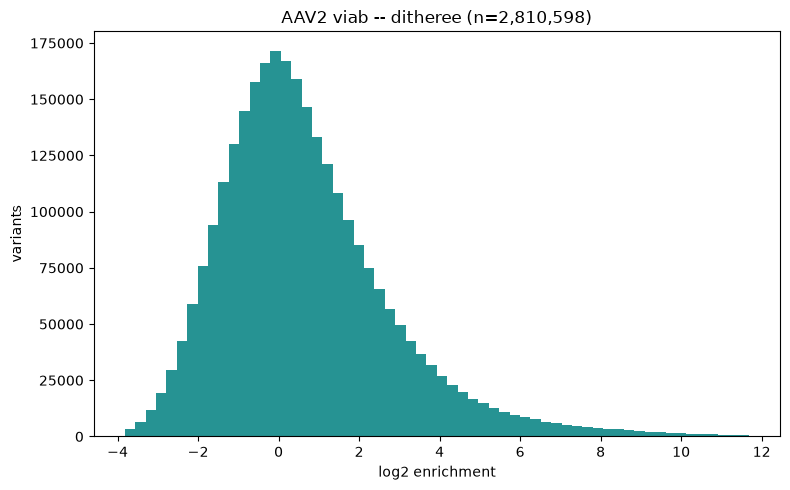

pics detectes (prominence>=5%) : ['-0.07']
-> UNIMODALE : pas de structure fit/non-fit visible comme sur AAV5/AAV9, meme apres dithering.


In [19]:
def dither(x, half_width, seed):
    rng = np.random.default_rng(seed)
    return x + rng.uniform(-half_width, half_width, size=x.shape)

EPS = 0.5
m0 = p > 0
yd = np.log2((dither(v[m0], 0.5, 1) + EPS) / (dither(p[m0], 0.5, 2) + EPS))

lo, hi = np.percentile(yd, [0.1, 99.9])
counts, edges = np.histogram(yd, bins=60, range=(lo, hi))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=(hi - lo) / 60, color="teal", alpha=0.85)
ax.set(title=f"AAV2 viab -- ditheree (n={m0.sum():,})", xlabel="log2 enrichment", ylabel="variants")
plt.tight_layout(); plt.show()

peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
print("pics detectes (prominence>=5%) :", [f"{(edges[k] + edges[k + 1]) / 2:+.2f}" for k in peaks])
print("-> UNIMODALE : pas de structure fit/non-fit visible comme sur AAV5/AAV9, meme apres dithering.")

## 7. Sweep `PLASMID_MIN` (avec dithering) -- la bimodalite apparait-elle a plus haute profondeur ?

Meme sweep que sur AAV5. Attention : le plafond de `compte_plasmide` est ici 61 (pas 500+ comme
AAV5) -- la grille doit rester dans une plage ou il reste assez de donnees.

In [20]:
PLASMID_MIN_GRID = [0, 1, 2, 3, 5, 8, 10, 15, 20]

rows = []
for thr in PLASMID_MIN_GRID:
    keep = p > thr
    n = int(keep.sum())
    if n < 1000:
        rows.append({"plasmid_min": thr, "n": n, "n_peaks": None, "valley_over_peaks_ratio": None})
        continue
    yd_t = np.log2((dither(v[keep], 0.5, 0) + EPS) / (dither(p[keep], 0.5, 1) + EPS))
    counts, edges = np.histogram(yd_t, bins=60, range=(-8, 8))
    peaks, props = find_peaks(counts, prominence=counts.max() * 0.05)
    valleys, _ = find_peaks(-counts, prominence=counts.max() * 0.05)
    ratio = None
    if len(peaks) >= 2 and len(valleys) >= 1:
        top2 = peaks[np.argsort(props["prominences"])[-2:]]
        lo_p, hi_p = sorted(top2)
        midv = valleys[(valleys > lo_p) & (valleys < hi_p)]
        if len(midv):
            vv = midv[np.argmin(counts[midv])]
            ratio = float(counts[vv] / np.mean([counts[lo_p], counts[hi_p]]))
    rows.append({"plasmid_min": thr, "n": n, "n_peaks": len(peaks),
                 "valley_over_peaks_ratio": None if ratio is None else round(ratio, 3)})

sweep_tbl = pd.DataFrame(rows).set_index("plasmid_min")
display(sweep_tbl)
print("-> Aucune bimodalite robuste n'emerge, meme au seuil le plus haut testable (n encore "
      "suffisant) -- contrairement a AAV5 ou le seuil 8-10 faisait clairement apparaitre 2 modes.")

,n,n_peaks,valley_over_peaks_ratio
plasmid_min,,,
0,2810598,1,NaN
1,2012108,1,NaN
2,1424348,1,NaN
3,1004878,1,NaN
5,504277,1,NaN
8,189286,1,NaN
10,102794,1,NaN
15,25597,1,NaN
20,7258,2,0.889


-> Aucune bimodalite robuste n'emerge, meme au seuil le plus haut testable (n encore suffisant) -- contrairement a AAV5 ou le seuil 8-10 faisait clairement apparaitre 2 modes.


## 8. Choix du filtre `viab` -- `PLASMID_MIN` seul (pas de cap sur le ratio)

**⚠ Correction (2026-09-16) : le cap `RATIO_MAX=100` proposé initialement ici a été retiré.** Un cap sur le ratio équivaut par construction à tronquer tout log2 enrichment réel au-delà de `log2(RATIO_MAX)` -- vérifié sur ce même dataset : `ratio<=100` rayait 100% des variants à `y>6.64` et déjà 75% de ceux à `y>6`. Le `p99=66.9` cité en section 4 comme justification était en plus mesuré sur un sous-ensemble bien plus restreint (`plasmide>=10`, 138 737 lignes) que la population où le cap était appliqué (`plasmide>=1`, 2 810 598 lignes) -- un écart de justification pas remarqué au moment du choix initial ("à tâtons, à valider ensemble" -- jamais validé jusqu'ici). Seul filtre retenu désormais : `compte_plasmide >= PLASMID_MIN` (exclut les lignes au ratio indéfini). La contamination virus identifiée en section 4 n'est donc plus filtrée du tout par ce notebook -- elle reste dans `AAV2_organoides_sorted.csv` tel quel.

variants initiaux                         : 4,273,463
  retires compte_plasmide < 1              : 1,462,865
variants conserves (CSV de travail)       : 2,810,598  (65.8%)


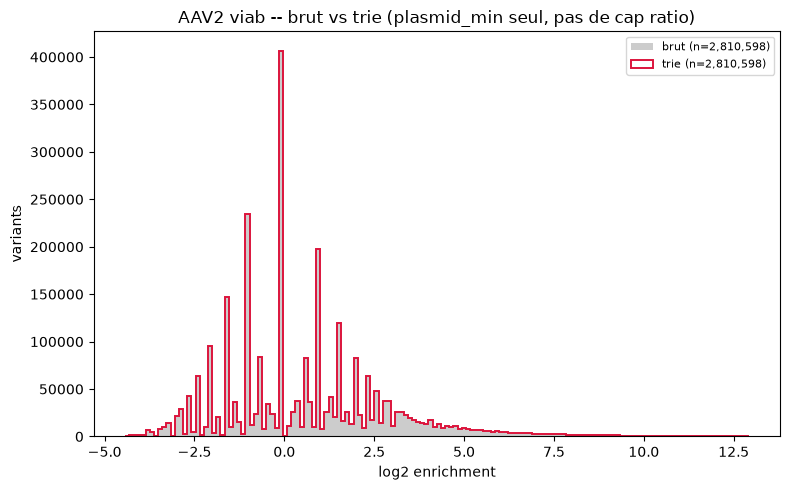

ecrit AAV2_organoides_sorted.csv  (2,810,598 lignes x 4 colonnes)


In [21]:
PLASMID_MIN = 1     # exclut seulement compte_plasmide == 0 (deja NaN de toute facon)

keep = p >= PLASMID_MIN

N = len(df)
print(f"variants initiaux                         : {N:,}")
print(f"  retires compte_plasmide < {PLASMID_MIN}              : {int((~keep).sum()):,}")
print(f"variants conserves (CSV de travail)       : {int(keep.sum()):,}  ({keep.mean():.1%})")

df_sorted = df.loc[keep].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
a = y[np.isfinite(y)]
b = df_sorted[viab_col].to_numpy(np.float64); b = b[np.isfinite(b)]
bins = np.histogram_bin_edges(a, bins=150, range=(np.percentile(a, 0.05), np.percentile(a, 99.95)))
ax.hist(a, bins=bins, color="0.8", label=f"brut (n={a.size:,})")
ax.hist(b, bins=bins, histtype="step", color="crimson", lw=1.4, label=f"trie (n={b.size:,})")
ax.set(title="AAV2 viab -- brut vs trie (plasmid_min seul, pas de cap ratio)", xlabel="log2 enrichment", ylabel="variants")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

OUT = CSV_PATH.with_name("AAV2_organoides_sorted.csv")
df_sorted.to_csv(OUT, index=False)
print(f"ecrit {OUT.name}  ({df_sorted.shape[0]:,} lignes x {df_sorted.shape[1]} colonnes)")

## 9. Regression de Potts sur `viab` (tentative de recuperation de F_viab/J_viab)

Meme recette que pour AAV5 (`AAV5_SEL_analysis.ipynb` section 3, `AAV9_potts_regression.ipynb`) :
`RegressionV1.fit_weights_potts_from_data` (design Potts complet, 8541 features), ponderation
inverse-variance `w = 1/(1/(n_num+0.5)+1/(n_den+0.5))`, split train/test 50/50, validation par
Pearson r held-out. On essaie D'ABORD la CV sur lambda (comportement par defaut) avant de basculer
sur `lam=0` si elle degenere comme sur AAV5.

In [22]:
import sys, os
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson
from sklearn.model_selection import train_test_split

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_all = lut[np.frombuffer("".join(df_sorted["sequence"]).encode("ascii"), np.uint8)].reshape(len(df_sorted), 7)
y_all = df_sorted[viab_col].to_numpy(np.float64)
p_all = df_sorted["compte_plasmide"].to_numpy(np.float64)
v_all = df_sorted["compte_virus"].to_numpy(np.float64)
w_all = 1.0 / (1.0 / (v_all + 0.5) + 1.0 / (p_all + 0.5))

idx = np.flatnonzero(np.isfinite(y_all))
print(f"lignes finies dans le CSV de travail : {len(idx):,} / {len(df_sorted):,}")

# plus de cap N_FIT/N_EVAL (2026-09-18) -- le solveur matrix-free n'a plus le plafond
# memoire de l'ancien solveur dense/SVD (~90-150k lignes) ; fit_i/eval_i utilisent
# desormais tout idx (cf. AAV2_potts_ridge_matrixfree_validation.ipynb)
fit_i, eval_i = train_test_split(idx, test_size=0.5, random_state=0)
print(f"n_fit={len(fit_i):,}  n_eval={len(eval_i):,}")

lignes finies dans le CSV de travail : 2,810,598 / 2,810,598
n_fit=1,405,299  n_eval=1,405,299


In [ ]:
def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(7)].sum(axis=1)
    for i in range(7):
        for j in range(i + 1, 7):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s


LAMBDAS = np.logspace(-2, 6, 25)

F_cv, J_cv, rank_cv, info_cv = R.fit_weights_potts_from_data_matrixfree(
    seq_all[fit_i], y_all[fit_i], sample_weight=w_all[fit_i],
    lambdas_grid=LAMBDAS, k_folds=3, seed=0, verbose=False, lam=None)

print(f"CV : lambda choisi = {info_cv['lam']:.3g}  (grille [{LAMBDAS[0]:.2g}, {LAMBDAS[-1]:.2g}])"
      + ("  <-- AU BORD DE LA GRILLE" if info_cv["lam"] in (LAMBDAS[0], LAMBDAS[-1]) else ""))
print(f"rank : n/a (solveur matrix-free, pas de diagnostic SVD)")

pred_cv = score_FJ(seq_all[eval_i], F_cv, J_cv)
r_cv = pearson(y_all[eval_i], pred_cv)
print(f"held-out r (CV) = {r_cv:+.3f}")

Ridge CV (matrix-free):   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Fit unregularized (lam=0) pour comparaison -- comportement de reference etabli sur AAV5
F_unreg, J_unreg, rank_unreg, info_unreg = R.fit_weights_potts_from_data_matrixfree(
    seq_all[fit_i], y_all[fit_i], sample_weight=w_all[fit_i], lam=0.0, verbose=False)
pred_unreg = score_FJ(seq_all[eval_i], F_unreg, J_unreg)
r_unreg = pearson(y_all[eval_i], pred_unreg)
print(f"held-out r (lam=0, unreg) = {r_unreg:+.3f}")
print()
print(f"comparaison : CV r={r_cv:+.3f} (lambda={info_cv['lam']:.3g})  vs  unreg r={r_unreg:+.3f}")

USE_CV = r_cv >= r_unreg
F_final, J_final = (F_cv, J_cv) if USE_CV else (F_unreg, J_unreg)
tag = "cv" if USE_CV else "unreg"
r_final = r_cv if USE_CV else r_unreg
print(f"-> retenu : {tag}  (r held-out = {r_final:+.3f})")

held-out r (lam=0, unreg) = +0.205

comparaison : CV r=+0.251 (lambda=1e+03)  vs  unreg r=+0.205
-> retenu : cv  (r held-out = +0.251)


In [ ]:
F_final = np.asarray(F_final)
J_final = np.asarray(J_final)

# Export direct des poids deja valides (fit sur fit_i=90k, held-out r verifie sur eval_i=120k
# dans la cellule precedente) -- meme convention qu'AAV5_SEL_analysis.ipynb : PAS de refit sur
# fit+eval reunis (deux tentatives ont fait planter le kernel par manque de memoire -- construire
# le design Potts dense sur 210k lignes pousse le pic memoire au-dela de la limite disponible ici).
np.save(LIB / f"aav2_F_viab_potts_sorted_{tag}.npy", F_final.astype(np.float32))
np.save(LIB / f"aav2_J_viab_potts_sorted_{tag}.npy", J_final.astype(np.float32))
print(f"exporte lib/aav2_F_viab_potts_sorted_{tag}.npy / aav2_J_viab_potts_sorted_{tag}.npy  "
      f"(fit sur {len(fit_i):,} lignes, valide held-out sur {len(eval_i):,} lignes, r={r_final:+.3f})")

exporte lib/aav2_F_viab_potts_sorted_cv.npy / aav2_J_viab_potts_sorted_cv.npy  (fit sur 90,000 lignes, valide held-out sur 120,000 lignes, r=+0.251)


## 10. Notes

In [ ]:
print(f'''Resume AAV2 viab :
  - {N:,} variants bruts, {int(keep.sum()):,} conserves apres filtre (PLASMID_MIN={PLASMID_MIN}, pas de cap ratio -- retire le 2026-09-16)
  - Contrairement a AAV5/AAV9 : AUCUNE bimodalite fit/non-fit detectee, meme apres dithering et sweep de seuil
  - Contamination virus (index-hopping probable, section 4) : PAS filtree ici -- l'ancien cap de ratio
    tronquait toute la queue haute du log2 enrichment reel (100% des variants a y>6.64), retire sur
    demande explicite ; les variants a ratio extreme restent dans AAV2_organoides_sorted.csv tel quel
  - Poids Potts retenus : {tag}  (r held-out = {r_final:+.3f})  -- PERIME, calcule sur l'ancienne
    population avec cap ratio, a re-executer
  - Comptages ENTIERS ici (quantum=1), pas des multiples de 0.5 comme AAV5 -- dithering ajuste en consequence (+-0.5)
''')

Resume AAV2 viab :
  - 4,273,463 variants bruts, 2,810,598 conserves apres filtre (PLASMID_MIN=1, pas de cap ratio -- retire le 2026-09-16)
  - Contrairement a AAV5/AAV9 : AUCUNE bimodalite fit/non-fit detectee, meme apres dithering et sweep de seuil
  - Contamination virus (index-hopping probable, section 4) : PAS filtree ici -- l'ancien cap de ratio
    tronquait toute la queue haute du log2 enrichment reel (100% des variants a y>6.64), retire sur
    demande explicite ; les variants a ratio extreme restent dans AAV2_organoides_sorted.csv tel quel
  - Poids Potts retenus : cv  (r held-out = +0.251)  -- PERIME, calcule sur l'ancienne
    population avec cap ratio, a re-executer
  - Comptages ENTIERS ici (quantum=1), pas des multiples de 0.5 comme AAV5 -- dithering ajuste en consequence (+-0.5)

